# Exercises week 36

**FYS-STK3155/4155, fall 2026 — deadline Friday September 4 at midnight.**

The aim this week is that you own the two central results of Monday's lecture
— the statistics of the OLS estimator and the bias-variance decomposition,
Eq. (2.52) of the book — and the two resampling tools, the bootstrap and
$k$-fold cross-validation. The code you developed in the Tuesday session
(`week36tuesday.ipynb`) is meant to be reused here, and everything in this set
is directly reusable in Project 1.

Reading: Chapter 2, Sections 2.3–2.12 of the book; Hastie et al., Sections
7.1–7.5, 7.10 and 7.11.

## Exercise 1: Analytical exercises — the statistics of the OLS estimator

Assume the data are generated by the linear model of Eq. (2.37),
$\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon}$,
with independent noise $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ and a
fixed (non-stochastic) design matrix $\boldsymbol{X}$ of dimension $n \times p$.

**1a)** Show that the expectation value and variance of a single output are
(Eq. (2.39))

$$
\mathbb{E}[y_i] = \boldsymbol{X}_{i,*}\,\boldsymbol{\theta},
\qquad
\mathrm{Var}(y_i) = \sigma^2 .
$$

**1b)** Show that the OLS estimator is unbiased,
$\mathbb{E}[\hat{\boldsymbol{\theta}}] = \boldsymbol{\theta}$ (Eq. (2.45)), and
derive its variance (Eq. (2.47)),

$$
\mathrm{Var}(\hat{\boldsymbol{\theta}}) = \sigma^2\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}.
$$

*Hint:* use
$\mathbb{E}[\boldsymbol{y}\boldsymbol{y}^T] = \boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T + \sigma^2\boldsymbol{I}_{nn}$.

**1c)** Optional: Explain how the diagonal elements of
$\sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}$ give a confidence interval for
the coefficient $\theta_j$ (Eq. (2.48)), and why in practice $\sigma^2$ is
replaced by
$\hat{\sigma}^2 = \|\boldsymbol{y}-\boldsymbol{X}\hat{\boldsymbol{\theta}}\|_2^2/(n-p)$.
Where does the $n-p$ come from? (Think of Bessel's correction, Eq. (2.28).)

1a)

Since the expectation value is defined as the integral over our variable multiplied with the probability distribution that the variable follows, we can simplify the problem by looking at what within $y$ actually depends on a probability distribution.
$\\$
y is defined as:
$\\$
$\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon}$
$\\$ And $\\$
$y_i = \sum_{i} X_{ij} \theta_{j}$
$\\$
Where the design matrix $\boldsymbol{X}$ in this case is non-stochastic, meaning it does not follow a probability distribution. Theta is just discrete values, and the noise have been assigned to the normal distribution. $\\$
The noise is therefor the only variable depending on a probability function, the normal distribution, and the parameters have been given as $ \mathcal{N}(0, \sigma^2)$
$\\$
This further tells us that the gaussian shape is centered around 0, meaning the expected value of the noise is 0. 
$\\$
Thinking back to the definition of expectation values, we understand that the $\boldsymbol{X}\boldsymbol{\theta}$ term can be moved out of the integral, and that the noise term equals zero. Finally we get the result:$\\$ 
$\mathbb{E}[y_i] = \boldsymbol{X}_{i,*}\,\boldsymbol{\theta}\qquad$


The arguments for the variance is similar: Using the fact that only the noise is dependent on a probability distribution we can regard only the parameters given in the normal distribution. Here the parameters for the standard deviation is the same as the variance $\sigma^2$, giving us: $\\$
$\mathrm{Var}(y_i) = \sigma^2$

1b)

We have that:

$\\$
$\boldsymbol{\hat{\theta}} = (\boldsymbol{X}^T \boldsymbol{X})^{-1} \boldsymbol{X}^T \boldsymbol{y}$
$\\$

And the result from 1a: $\\$

$\mathbb{E}[y] = \boldsymbol{X} \boldsymbol{ \theta}$
$\\$

Using the same argument as in 1a we can apply the expectation value only on parameters that are dependent: 

$\\$
$\mathbb{E}[\hat{\boldsymbol{\theta}}] = (\boldsymbol{X}^T \boldsymbol{X})^{-1} \boldsymbol{X}^T \mathbb{E}[y]$
$\\$
$\mathbb{E}[\hat{\boldsymbol{\theta}}] = (\boldsymbol{X}^T \boldsymbol{X})^{-1} \boldsymbol{X}^T \boldsymbol{X} \boldsymbol{ \theta} = \boldsymbol{\theta}$


Deriving the Variance:

$\mathrm{Var}(\hat{\boldsymbol{\theta}}) = \mathbb{E}[\hat{\boldsymbol{\theta}}\hat{\boldsymbol{\theta}}^T ] - \boldsymbol{\theta}\boldsymbol{\theta}^T$

Using both:

$\boldsymbol{\hat{\theta}} = (\boldsymbol{X}^T \boldsymbol{X})^{-1} \boldsymbol{X}^T \boldsymbol{y}$

$ \boldsymbol{\hat{\theta}}^T = \boldsymbol{y}^T \boldsymbol{X} (\boldsymbol{X}^T \boldsymbol{X})^{-1}$

And putting these in the variance equation:

$\mathrm{Var}(\hat{\boldsymbol{\theta}}) = \mathbb{E}[(\boldsymbol{X}^T \boldsymbol{X})^{-1} \boldsymbol{X}^T \boldsymbol{y}  \boldsymbol{y}^T \boldsymbol{X} (\boldsymbol{X}^T \boldsymbol{X})^{-1}] - \boldsymbol{\theta}\boldsymbol{\theta}^T$

We can draw out the non-stochastic variables:

$\mathrm{Var}(\hat{\boldsymbol{\theta}}) = (\boldsymbol{X}^T \boldsymbol{X})^{-1} \boldsymbol{X}^T  \mathbb{E}[\boldsymbol{y}  \boldsymbol{y}^T]  \boldsymbol{X} (\boldsymbol{X}^T \boldsymbol{X})^{-1} - \boldsymbol{\theta}\boldsymbol{\theta}^T$

Using the hint:

$\mathbb{E}[\boldsymbol{y}\boldsymbol{y}^T] = \boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T + \sigma^2\boldsymbol{I}_{nn}$

$\mathrm{Var}(\hat{\boldsymbol{\theta}}) = (\boldsymbol{X}^T \boldsymbol{X})^{-1} \boldsymbol{X}^T  \{\boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T + \sigma^2\boldsymbol{I}_{nn}\}  \boldsymbol{X} (\boldsymbol{X}^T \boldsymbol{X})^{-1} - \boldsymbol{\theta}\boldsymbol{\theta}^T$

$\mathrm{Var}(\hat{\boldsymbol{\theta}}) = 
(\boldsymbol{X}^T \boldsymbol{X})^{-1} \boldsymbol{X}^T \boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T \boldsymbol{X} (\boldsymbol{X}^T \boldsymbol{X})^{-1} + (\boldsymbol{X}^T \boldsymbol{X})^{-1} \boldsymbol{X}^T\sigma^2\boldsymbol{I}_{nn} \boldsymbol{X} (\boldsymbol{X}^T \boldsymbol{X})^{-1} - \boldsymbol{\theta}\boldsymbol{\theta}^T$

$\mathrm{Var}(\hat{\boldsymbol{\theta}}) = \boldsymbol{\theta}\boldsymbol{\theta}^T + (\boldsymbol{X}^T \boldsymbol{X})^{-1} \boldsymbol{X}^T\boldsymbol{X} \sigma^2 (\boldsymbol{X}^T \boldsymbol{X})^{-1} - \boldsymbol{\theta}\boldsymbol{\theta}^T$

$\mathrm{Var}(\hat{\boldsymbol{\theta}}) = \boldsymbol{\theta}\boldsymbol{\theta}^T +\sigma^2 (\boldsymbol{X}^T \boldsymbol{X})^{-1} - \boldsymbol{\theta}\boldsymbol{\theta}^T$

$\mathrm{Var}(\hat{\boldsymbol{\theta}}) =\sigma^2 (\boldsymbol{X}^T \boldsymbol{X})^{-1} $

## Exercise 2: Analytical exercises — deriving the bias-variance tradeoff

Assume now, as in Section 2.10, that the true data are generated by
$\boldsymbol{y} = f(\boldsymbol{x}) + \boldsymbol{\varepsilon}$ with
$\boldsymbol{\varepsilon} \sim \mathcal{N}(0, \sigma^2)$ (Eq. (2.49)), and let
$\tilde{\boldsymbol{y}}$ be the prediction of a model fitted on a randomly
drawn training set.

**2a)** Starting from the expected squared error
$\mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2]$ and adding and
subtracting $\mathbb{E}[\tilde{\boldsymbol{y}}]$, derive the decomposition of
Eq. (2.52),

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
= \frac{1}{n}\sum_i\left(f_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \sigma^2 .
$$

Show explicitly that all three cross terms vanish, stating for each one which
assumption kills it (zero-mean noise, independence of noise and training set,
$f$ non-stochastic).

**2b)** Explain in your own words what the expectation
$\mathbb{E}[\cdot]$ runs over, and what each of the three terms means for the
polynomial-fit example of the lecture.

**2c)** In the numerical estimate (Tuesday's Case 1) the bias is computed
against $y_{\mathrm{test}}$ rather than the unknown $f$. Show that the
measured "bias" then contains $\sigma^2$, so the printed identity
`error >= bias + variance` is an inequality.

2a)

Starting from:

$ \mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2]
= \mathbb{E}[(\boldsymbol{f} + \epsilon -  \tilde{\boldsymbol{y}})^2]$

We add and subtract $\mathbb{E}[\tilde{\boldsymbol{y}}]$:

$ \mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2]
= \mathbb{E}[(\boldsymbol{f} + \epsilon -  \tilde{\boldsymbol{y}} + \mathbb{E}[\tilde{\boldsymbol{y}}] - \mathbb{E}[\tilde{\boldsymbol{y}}])^2]$

Rearranging and expanding the square:

$( (\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}]) + \epsilon  + (\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}})  )^2 = (\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2 + (\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}])\epsilon + (f - \mathbb{E}[\tilde{\boldsymbol{y}}])(\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}}) + \epsilon(\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}]) + \epsilon^2 + \epsilon(\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}}) + (f - \mathbb{E}[\tilde{\boldsymbol{y}}])(\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}}) + (\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}})\epsilon + (\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}})^2 $

$ = (\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2 + 2(\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}])\epsilon + 2(f - \mathbb{E}[\tilde{\boldsymbol{y}}])(\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}}) + \epsilon^2 + 2 \epsilon(\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}}) + (\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}})^2$

Writing the whole expression:

$ \mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2] = \mathbb{E}[(\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2 + 2(\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}])\epsilon + 2(f - \mathbb{E}[\tilde{\boldsymbol{y}}])(\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}}) + \epsilon^2 + 2 \epsilon(\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}}) + (\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}})^2] $

Where $\boldsymbol{f}$ is non-stochastic,  $\mathbb{E}[\tilde{\boldsymbol{y}}]$ is a constant, and the expectation value of $\epsilon$ is 0 since the expectation value of the noise is 0, given by the normal distribution. This makes the terms containing these variables 0:

$ \mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2] = \mathbb{E}[(\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2 + 2(f - \mathbb{E}[\tilde{\boldsymbol{y}}])(\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}}) + \epsilon^2 + 2 \epsilon(\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}}) + (\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}})^2] $


Changing the signs of some terms to match the final expression:

$ \mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2] = \mathbb{E}[(\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2 + 2(f - \mathbb{E}[\tilde{\boldsymbol{y}}])(-1)(\tilde{\boldsymbol{y}}- \mathbb{E}[\tilde{\boldsymbol{y}}]) + \epsilon^2 - 2 \epsilon(\tilde{\boldsymbol{y}} - \mathbb{E}[\tilde{\boldsymbol{y}}]) + (\tilde{\boldsymbol{y}} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2] $

Using that $ \mathbb{E}[\tilde{\boldsymbol{y}} - \mathbb{E}[\tilde{\boldsymbol{y}}]] = 0$ 

=> 
$ \mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2] = \mathbb{E}[(\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2 + \epsilon^2 + (\tilde{\boldsymbol{y}} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2]$

Looking at the terms seperatly:

$\mathbb{E}[(\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2$]: $\\$
This whole term is a constant, since f is non-stochastic and $\mathbb{E}[\tilde{\boldsymbol{y}}$ is a constant. The expectation value of a constant is just the constant itself. 

$\mathbb{E}[\epsilon^2]$:
$\\$
$Var(\epsilon) = \mathbb{E}[\epsilon^2] - (\mathbb{E}[\epsilon])^2 = \sigma^2 - 0 = \sigma^2$
Which comes from the parameters given in the normal distribution of the noise. 
=> $\mathbb{E}[\epsilon^2] = \sigma^2$

$\mathbb{E}[(\tilde{\boldsymbol{y}} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2]$: $\\$
This is the definition of variance, which can be rewritten in the form found in Eq. 2.52.

Finally, this gives the result:

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
= \frac{1}{n}\sum_i\left(f_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \sigma^2.
$$

2b)

The expectation runs over the predicted y-value in each bootstrap resample for a specific point x, and the final calculated number is found by averaging these specific points results over all n. 

The bias term specifically calculates how far the average prediction is from the true function f. For low polynomial degrees the model is simply not complex enough to fit the true function, and the bias will be relatively high.
The variance term tells us how much the predicted y value varies across the resampled training sets. For high polynomial degrees the model will increasingly fitted towards the random noise in each training set, making the variation across them higher.  
$\sigma^2$ is the irreducible noise - the random variation in data that no model can eliminate. For higher polynomial degrees the noise affects the model much more, as discussed above. 

2c)

Looking at the bias term:
$\frac{1}{n}\sum_i\left(f_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2$

Replacing f with $y_{test}$

=> $\frac{1}{n}\sum_i\left(y_{test,i}-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2$

Where $y_{test,i} = f_i + \epsilon$

=> $\frac{1}{n}\sum_i\left(f_i + \epsilon-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2$

Rearranging and expanding the square:

$\frac{1}{n}\sum_i\left((f_i -\mathbb{E}[\tilde{\boldsymbol{y}}]\right) + \epsilon)^2$

$\frac{1}{n}\sum_i((f_i -\mathbb{E}[\tilde{\boldsymbol{y}}])^2 + 2\epsilon(f_i -\mathbb{E}[\tilde{\boldsymbol{y}}]) + \epsilon^2)$

$\frac{1}{n}\sum_i(f_i -\mathbb{E}[\tilde{\boldsymbol{y}}])^2 + \frac{1}{n}\sum_i(2\epsilon(f_i -\mathbb{E}[\tilde{\boldsymbol{y}}])) + \frac{1}{n}\sum_i(\epsilon^2)$

Looking at the cross term $\frac{1}{n}\sum_i(2\epsilon(f_i -\mathbb{E}[\tilde{\boldsymbol{y}}]))$:$\\$
we know that the average value of noise is 0, as argumenter for in previous exercises. This makes the whole term 0. 

The term $\frac{1}{n}\sum_i(\epsilon^2)$ becomes $\sigma^2$ since this calculates the average of the squared noise. This was also found earlier by $\mathbb{E}[\epsilon^2] = \sigma^2$. 

This leaves:
$\frac{1}{n}\sum_i(f_i -\mathbb{E}[\tilde{\boldsymbol{y}}])^2 + \sigma^2$

Which is the measured bias also containing noise. 



## Exercise 3: The bias-variance tradeoff with the bootstrap

We use the same data as in the Tuesday session (and as in last week's
exercise 3),

$$
y = e^{-x^2} + 1.5\,e^{-(x-2)^2} + \varepsilon,
\qquad \varepsilon \sim \mathcal{N}(0, 0.1^2),
$$

on $x \in [-3, 3]$.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample

# the color palette used in the weekly slides
BLUE, RED, YELLOW = "#004488", "#BB5566", "#DDAA33" 

np.random.seed(2026)
n = 40
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)

1. Split the data in training and test parts (80/20). For polynomial degrees
   $0$ to $13$, use the bootstrap (100 resamples of the training data) to
   estimate the test error, the squared bias and the variance, and plot the
   three curves as functions of the degree (compare with
   `week36_bias_variance.pdf` from the lecture — with seed 2026 you should
   reproduce it).
2. Discuss the figure in terms of Eq. (2.52): where is the model dominated by
   bias, where by variance, and where would you place the optimal degree?
3. Repeat the analysis for $n = 100$ and $n = 400$ data points and comment on
   how the curves and the optimal degree move.
4. Replace OLS by Ridge regression at a fixed high degree (say 12) and study
   the three terms as functions of $\lambda$ (for example
   `np.logspace(-6, 2, 9)`). Which term does $\lambda$ attack, and at what
   cost?

1.

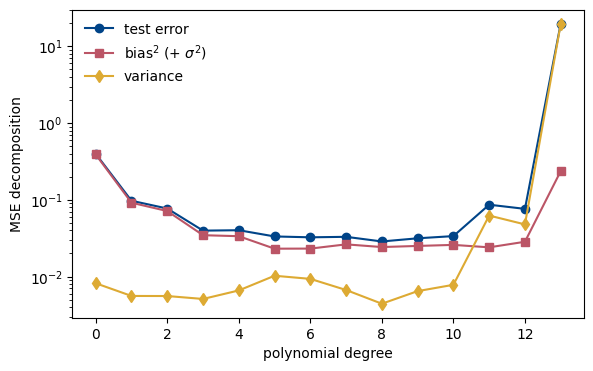

degree  0: error 0.3980  bias^2 0.3898  var 0.0082  sum 0.3980
degree  4: error 0.0401  bias^2 0.0336  var 0.0066  sum 0.0401
degree  8: error 0.0286  bias^2 0.0242  var 0.0044  sum 0.0286
degree 13: error 19.7520  bias^2 0.2367  var 19.5153  sum 19.7520


In [6]:
# Your code for exercise 3 here

n_bootstraps, maxdegree = 100, 14
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2026)

error = np.zeros(maxdegree)
bias = np.zeros(maxdegree)
variance = np.zeros(maxdegree)
for degree in range(maxdegree):
    model = make_pipeline(PolynomialFeatures(degree=degree),
                          LinearRegression(fit_intercept=False)) # creating the design matrix create linear regression space
    y_pred = np.empty((y_test.shape[0], n_bootstraps)) # creating array for predicted y of all resampled training data
    for i in range(n_bootstraps): # going through each bootstrap resample
        x_, y_ = resample(x_train, y_train) 
        y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel() # finding predicted y values for specific resample data, predicting with OLS method

    # Expectations over training sets are averages along axis 1;
    # keepdims=True preserves the column shape and is essential
    # for the bias to come out right.
    error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
    bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2) # squared bias
    variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(range(maxdegree), error, "o-", color=BLUE, label="test error")
ax.plot(range(maxdegree), bias, "s-", color=RED, label=r"bias$^2$ (+ $\sigma^2$)")
ax.plot(range(maxdegree), variance, "d-", color=YELLOW, label="variance")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE decomposition")
ax.legend(frameon=False)
plt.show()

for d in (0, 4, 8, maxdegree - 1):
    print(f"degree {d:2d}: error {error[d]:.4f}  bias^2 {bias[d]:.4f}  "
          f"var {variance[d]:.4f}  sum {bias[d] + variance[d]:.4f}")

We see that the plot corresponds to the one in the tuesday lecture case 1. 


2.

Looking at the plot we see an increase in MSE for low polynomial degrees. This represents underfitting, meaning the polynomial degree is not complex enough for the model to correspond with the true values. Here bias is dominating: The predicted values are not necessarily spread, but they are further from the true values as the approximated function does not have enough parameters to resemble the true function.

Between polynomial degrees ~ 4-10 we find the lowest MSE values, meaning the optimal polynomial degree is within this range. The model is able to reproduce the true values with the least error. 

For high polynomial degrees, we se a rapid increase in MSE. This comes from overfitting, meaning the complex model starts fitting to the noise in the training data, and the variance between the predicted y values become higher. The variance is therefor dominating. 

3.

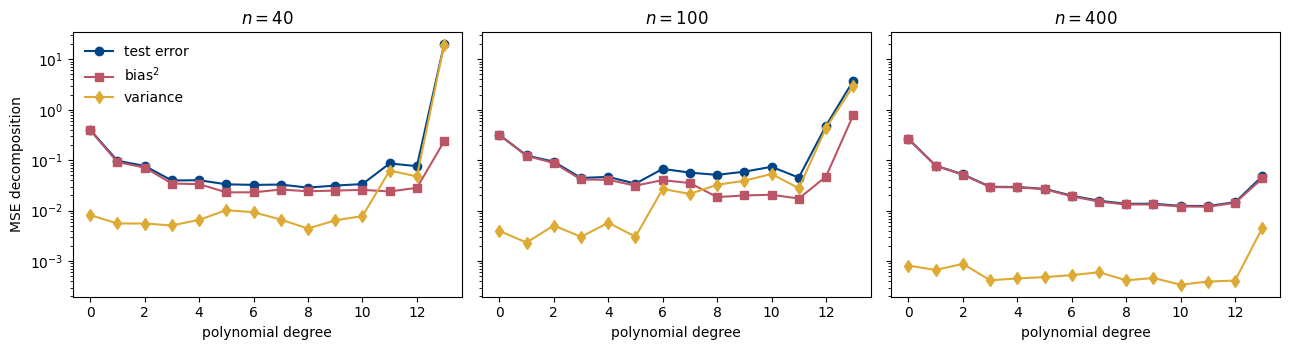

In [7]:
def bias_variance_sweep(n=40, noise=0.1, maxdegree=14, n_bootstraps=100,
                        make_model=None, seed=2026):
    """Bootstrap estimate of error/bias^2/variance vs polynomial degree."""
    if make_model is None:
        make_model = lambda deg: make_pipeline(
            PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))
    np.random.seed(seed)
    x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, noise, x.shape)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                        random_state=seed)
    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))
    for degree in range(maxdegree):
        model = make_model(degree)
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()
        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))
    return error, bias, variance


fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n_ in zip(axes, (40, 100, 400)):
    err, b2, var = bias_variance_sweep(n=n_)
    ax.plot(range(14), err, "o-", color=BLUE, label="test error")
    ax.plot(range(14), b2, "s-", color=RED, label=r"bias$^2$")
    ax.plot(range(14), var, "d-", color=YELLOW, label="variance")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

How curves and optimal degree moves:
For n = 100, the variance especially decrease for low polynomial degrees. This seems reasonable, if we have more data points the distance between them will become smaller as they 'fill up' more of the area where the data lies. 
This reasoning makes it logical that the MSE of the variance is even lower for n = 400.

The bias generally stays the same - this also makes sense at the bias is not affected by number of datapoints. Bias is only affected by systematic errors, as the bias only decrease if we improve the fit of the model. 

4.

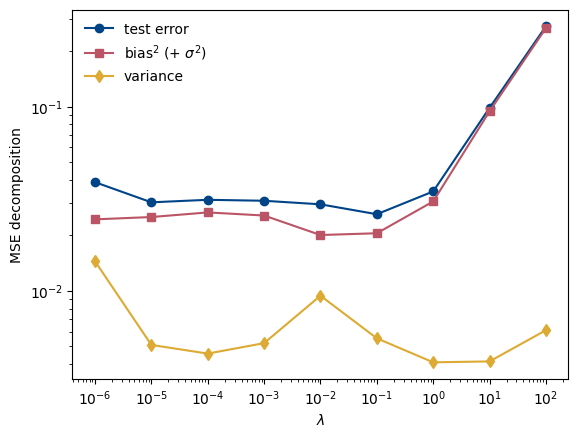

lambda 1e-06: error 0.0389  bias^2 0.0244  var 0.0145  sum 0.0389
lambda 1e-05: error 0.0302  bias^2 0.0251  var 0.0051  sum 0.0302
lambda 1e-04: error 0.0312  bias^2 0.0266  var 0.0046  sum 0.0312
lambda 1e-03: error 0.0308  bias^2 0.0256  var 0.0052  sum 0.0308
lambda 1e-02: error 0.0295  bias^2 0.0201  var 0.0094  sum 0.0295
lambda 1e-01: error 0.0260  bias^2 0.0205  var 0.0055  sum 0.0260
lambda 1e+00: error 0.0346  bias^2 0.0305  var 0.0041  sum 0.0346
lambda 1e+01: error 0.0984  bias^2 0.0943  var 0.0041  sum 0.0984
lambda 1e+02: error 0.2729  bias^2 0.2668  var 0.0061  sum 0.2729


In [17]:
n_bootstraps, maxdegree = 100, 14
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2026)

lambdas = np.logspace(-6, 2, 9)
deg = 12

error = np.zeros(len(lambdas))
bias = np.zeros(len(lambdas))
variance = np.zeros(len(lambdas))

for index, lam in enumerate(lambdas):
    model = make_pipeline(PolynomialFeatures(degree=deg), StandardScaler(),Ridge(alpha=lam)) # creating the design matrix create linear regression space

    y_pred = np.empty((y_test.shape[0], n_bootstraps)) # creating array for predicted y of all resampled training data
    for i in range(n_bootstraps): # going through each bootstrap resample
        x_, y_ = resample(x_train, y_train) 
        y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel() # finding predicted y values for specific resample data, predicting with OLS method

    # Expectations over training sets are averages along axis 1;
    # keepdims=True preserves the column shape and is essential
    # for the bias to come out right.
    error[index] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
    bias[index] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2) # squared bias
    variance[index] = np.mean(np.var(y_pred, axis=1, keepdims=True))

fig, ax = plt.subplots()
ax.plot(lambdas, error, "o-", color=BLUE, label="test error")
ax.plot(lambdas, bias, "s-", color=RED, label=r"bias$^2$ (+ $\sigma^2$)")
ax.plot(lambdas, variance, "d-", color=YELLOW, label="variance")
ax.set_xscale("log") 
ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("MSE decomposition")
ax.legend(frameon=False)
plt.show()

for i, lam in enumerate(lambdas):
    print(f"lambda {lam:.0e}: error {error[i]:.4f}  bias^2 {bias[i]:.4f}  "
          f"var {variance[i]:.4f}  sum {bias[i] + variance[i]:.4f}")


Looking at the plot we se that the MSE of the bias rapidly increase for high lambda values. For high lambda values, the parameters are increasingly penalized, which results in a model that is effectivly non-complex. This has a simular effect on the model as using low polynomial degrees, which we found increased the bias. Therefor the bias is dominating for high lambda values.

The variance is generally a bit lower, but is slightly increased when lambda is small. Using the same logic, the fitted parameters in the model are now barely penalized at all, resulting in the ridge fit to approximately work as an OLS regression fit. The variance then dominates as a polynomial of degree 12 has been fitted, as discussed in the previous exercises.

Lambda attacks the variance term, which is seen by the overall decrease of variance MSE. This comes from the fact that ridge shrinks the coefficients and makes the model more rigid and less able to adapt to noise. This comes with the cost of increased bias, as a more rigid model will (in the same way) not adapt as easily to the true values.

## Exercise 4: Cross-validation

Still with the same type of data, we now select models without consuming a
test set.

1. Use scikit-learn's (or perhaps write your own) $k$-fold cross-validation function: shuffle the data,
   split into $k$ folds, use each fold as test set once, and return the mean
   and standard deviation over folds of the test MSE. Do **not** use
   `cross_val_score` inside your own function.
2. Use it with $k = 5$ to compute the CV estimate of the MSE for OLS with
   polynomial degrees $0$ to $13$, and compare with the bootstrap analysis of
   exercise 3: do the two methods point to the same degree window?
3. For a degree-6 polynomial with Ridge regression on
   $y = 3x^2 + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,1)$, $n=100$
   (Tuesday's Case 2), compute the CV MSE on
   `np.logspace(-3, 5, 100)` and find the optimal $\lambda$. Any
   scaling/preprocessing must be fitted **inside** each fold — explain in one
   or two sentences why.
4. Try $k = 5, 10$ and $n$ (leave-one-out). Comment on the stability of the
   selected $\lambda$ and on the computational cost.

1.

In [26]:
from sklearn.metrics import mean_squared_error

def mean_std_from_kfold(x,y,k,model):

    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    MSE_test = np.zeros(k)

    for i, (train_inds, test_inds) in enumerate(kfold.split(x)):
        xtrain, ytrain = x[train_inds], y[train_inds]
        xtest, ytest = x[test_inds], y[test_inds]

        model.fit(xtrain, ytrain)
        y_tilde_test = model.predict(xtest)

        MSE_test[i] = mean_squared_error(ytest, y_tilde_test)

    mean = np.mean(MSE_test)
    std = np.std(MSE_test)
    return mean, std

2.

In [31]:
maxdegree = 14
cv_mean = np.zeros(maxdegree)
cv_std = np.zeros(maxdegree)

for degree in range(maxdegree):
    model = make_pipeline(PolynomialFeatures(degree=degree),LinearRegression(fit_intercept=False))
    cv_mean[degree], cv_std[degree] = mean_std_from_kfold(x, y, k=5, model=model)


    

## Exercise 5 (optional): error bars from the bootstrap

Use the bootstrap to attach uncertainties to fitted parameters, where the
analytical formula of exercise 1 can be checked — and where it cannot.

1. For OLS on a degree-3 polynomial fit of the exercise-3 data, bootstrap the
   training data 1000 times and histogram the resulting
   $\hat{\theta}_j^*$. Compare the bootstrap standard deviations with the
   analytical standard errors
   $\hat{\sigma}\sqrt{[(\boldsymbol{X}^T\boldsymbol{X})^{-1}]_{jj}}$ of
   Eq. (2.48).
2. Repeat for Lasso with a small penalty. Why is the bootstrap now the only
   option on the table? (Which assumption behind Eq. (2.48) fails?)

In [4]:
# Your code for exercise 5 here

### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 4 at midnight**. Collaboration is encouraged — list
your collaborators.